## Sea surface current

In [1]:
import xarray as xr
import pandas as pd
from glob import glob

# Path to NetCDF files
data_dir = "/home/praktik/data"

# Collect NetCDF files
nc_files = sorted(glob(f"{data_dir}/oscar_currents_*.nc"))

# Optional: sanity check
print(f"Found {len(nc_files)} NetCDF files")
datasets = [xr.open_dataset(f) for f in nc_files]

# Concatenate manually along time
ds = xr.concat(datasets, dim="time")

# Convert to DataFrame
df = ds.to_dataframe().reset_index()
df = df.dropna()
df["time"] = pd.to_datetime([t.strftime("%Y-%m-%d %H:%M:%S") for t in df["time"]])
# Average over time for each (lat, lon)
df_avg = (
    df
    .groupby(['lat', 'lon'], as_index=False)
    .mean(numeric_only=True)
)

df_subset = df_avg[
    (df_avg['lat'] >= 33.364) & (df_avg['lat'] <= 64.73742) &
    (df_avg['lon'] >= 297.1683) & (df_avg['lon'] <= 348.2947)
]

Found 30 NetCDF files


In [2]:
len(df_subset)

23960

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your CSV is already loaded
# df = pd.read_csv("oscar_currents_jan2020.csv")

# Select a single timestamp
timestamp = pd.Timestamp("2020-01-01")
df_time = df[df["time"] == timestamp]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_subset = pd.read_csv("df_current.csv")

In [2]:
df_subset.head()

,lat,lon,longitude,latitude,u,v,ug,vg
0,30.0,300.00,1200.0,479.0,-0.172149,-0.006306,-0.171988,0.001179
1,30.0,300.25,1201.0,479.0,-0.149281,-0.010040,-0.148466,-0.000877
2,30.0,300.50,1202.0,479.0,-0.128321,-0.010929,-0.129801,-0.001292
3,30.0,300.75,1203.0,479.0,-0.107817,-0.006528,-0.111915,0.000748
4,30.0,301.00,1204.0,479.0,-0.082736,0.002116,-0.088275,0.009155


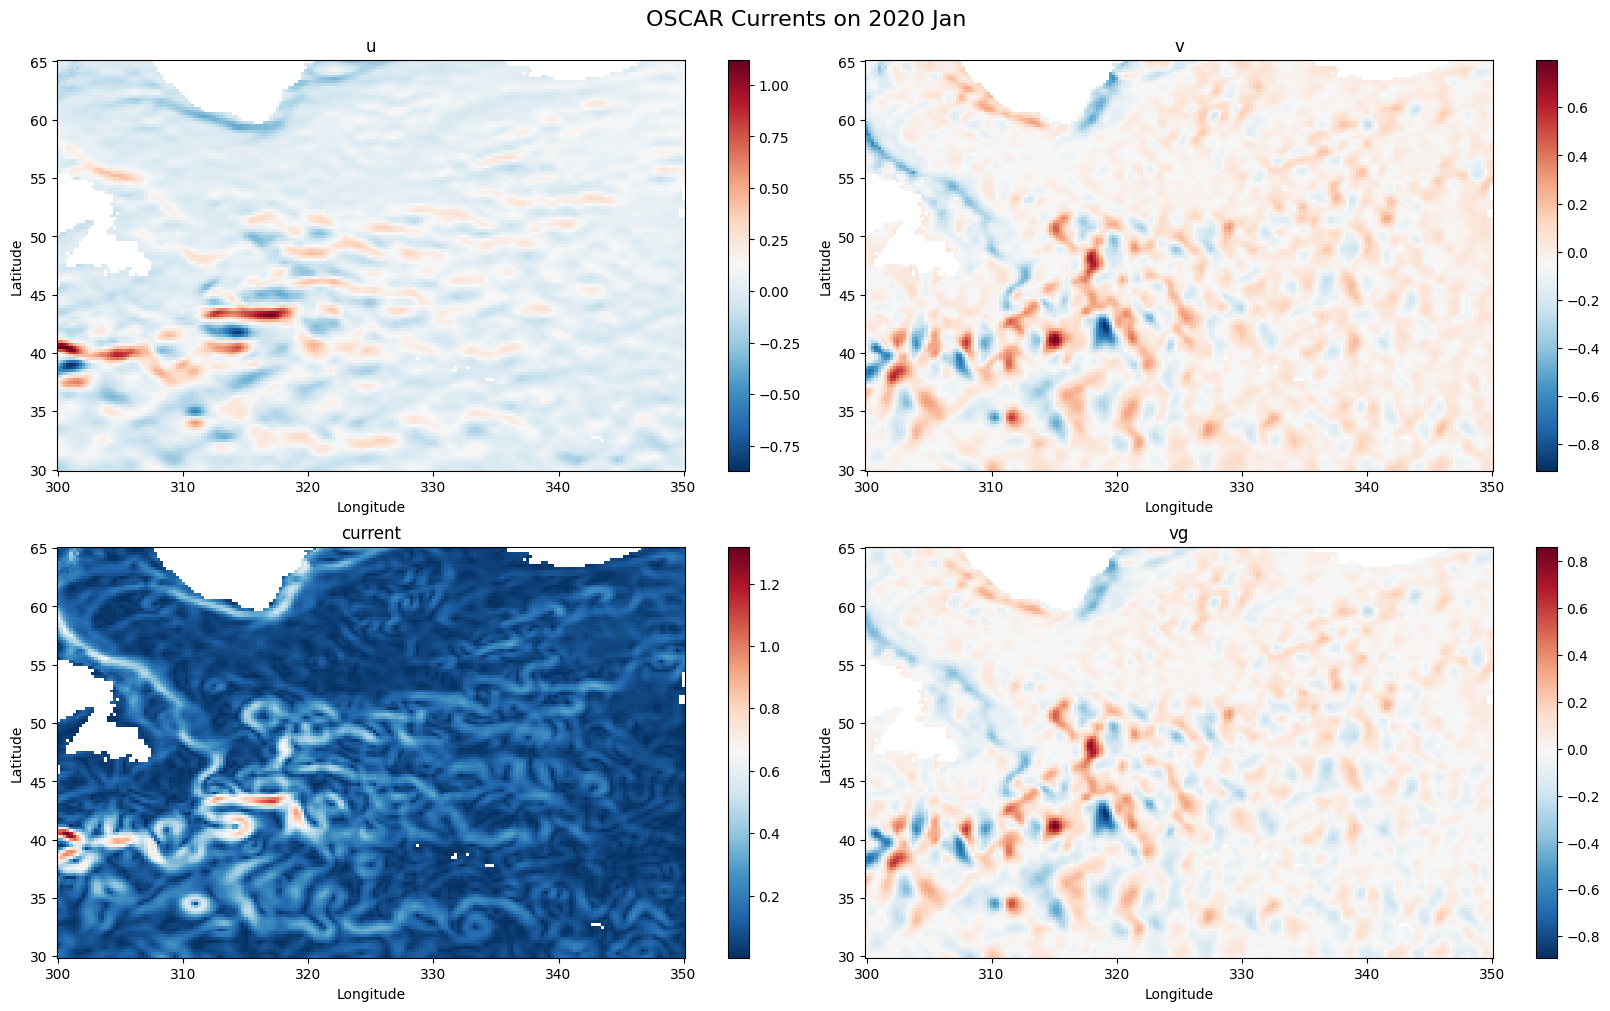

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# Create sorted coordinate arrays
lon = np.sort(df_subset["lon"].unique())
lat = np.sort(df_subset["lat"].unique())

# Create 2D coordinate grid
Lon, Lat = np.meshgrid(lon, lat)

def grid_from_df(df, var):
    return (
        df
        .pivot(index="lat", columns="lon", values=var)
        .sort_index(ascending=True)
        .values
    )

u  = grid_from_df(df_subset, "u")
v  = grid_from_df(df_subset, "v")
ug = grid_from_df(df_subset, "ug")
vg = grid_from_df(df_subset, "vg")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
cmap = "RdBu_r"

plots = [
    ("u",  u,  axes[0,0]),
    ("v",  v,  axes[0,1]),
    ("current", np.sqrt(v**2 + u**2), axes[1,0]),
    ("vg", vg, axes[1,1]),
]

for title, data, ax in plots:
    pcm = ax.pcolormesh(
        Lon, Lat, data,
        shading="auto",
        cmap=cmap
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(pcm, ax=ax)

plt.suptitle(f"OSCAR Currents on 2020 Jan", fontsize=16)
plt.savefig("oscar_currents.png", dpi=300, bbox_inches="tight")

plt.show()

In [3]:
df_subset.to_csv("df_current.csv", index=False)

## Argo data plots

In [22]:
df_argo = pd.read_csv("raw_datasets/argo3D.csv")

In [26]:
# Get index of smallest mean_pres for each (lon, lat)
idx = df_argo.groupby(['lon', 'lat'])['mean_pres'].idxmin()

df_min = df_argo.loc[idx].reset_index(drop=True)

In [27]:
heatmap_data = df_min.pivot(
    index='lat',
    columns='lon',
    values='mean_temp'
)

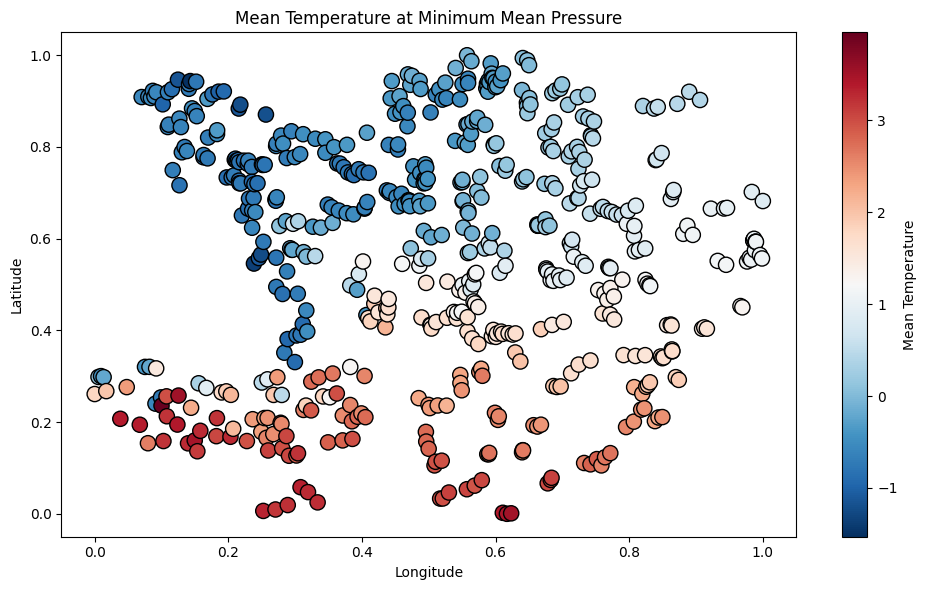

In [30]:
plt.figure(figsize=(10, 6))

sc = plt.scatter(
    df_min['lon'],
    df_min['lat'],
    c=df_min['mean_temp'],
    cmap='RdBu_r',
    s=120,          # dot size (increase if needed)
    edgecolors='k'  # black edge for visibility
)

plt.colorbar(sc, label='Mean Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mean Temperature at Minimum Mean Pressure')

plt.tight_layout()
plt.savefig("argo_data.png", dpi=300, bbox_inches="tight")
plt.show()

## SST data pre-processing 

In [ ]:
import xarray as xr
import pandas as pd
from glob import glob
import numpy as np

# Path to NetCDF files
data_dir = "/home/praktik/data"

# Collect NetCDF files
nc_files = sorted(glob(f"{data_dir}/*04.2.nc"))

# Optional: sanity check
print(f"Found {len(nc_files)} NetCDF files")
datasets = [xr.open_dataset(f) for f in nc_files]

# Concatenate manually along time
ds = xr.concat(datasets, dim="time")

# Convert to DataFrame
df = ds.to_dataframe().reset_index()



Found 31 NetCDF files
32140800
720


NameError: name 'lon' is not defined

In [87]:
df["time"] = pd.to_datetime([t.strftime("%Y-%m-%d %H:%M:%S") for t in df["time"]])


In [3]:
# Average over time for each (lat, lon)
df_avg = (
    df
    .groupby(['lat', 'lon'], as_index=False)
    .mean(numeric_only=True)
)

df_subset = df_avg[
    (df_avg['lat'] >= 33.364) & (df_avg['lat'] <= 64.73742) &
    (df_avg['lon'] >= -62.83174) & (df_avg['lon'] <= -11.7053)
]

df_subset['analysed_sst'] = df_subset['analysed_sst'] - 273.15

In [93]:
df_subset

,lat,lon,analysed_sst,analysis_error,mask,sea_ice_fraction,sst_anomaly
492758,30.125,-59.875,22.266387,0.378710,1.0,NaN,0.805548
492759,30.125,-59.625,22.285161,0.377742,1.0,NaN,0.905290
492760,30.125,-59.375,22.325742,0.377419,1.0,NaN,1.008581
492761,30.125,-59.125,22.335226,0.378065,1.0,NaN,0.947839
492762,30.125,-58.875,22.297806,0.379677,1.0,NaN,0.903935
...,...,...,...,...,...,...,...
588570,64.875,-11.125,4.631774,0.359677,1.0,NaN,0.656581
588571,64.875,-10.875,4.816032,0.359677,1.0,NaN,0.761032
588572,64.875,-10.625,4.975161,0.359677,1.0,NaN,0.953968
588573,64.875,-10.375,4.879613,0.359355,1.0,NaN,0.948226


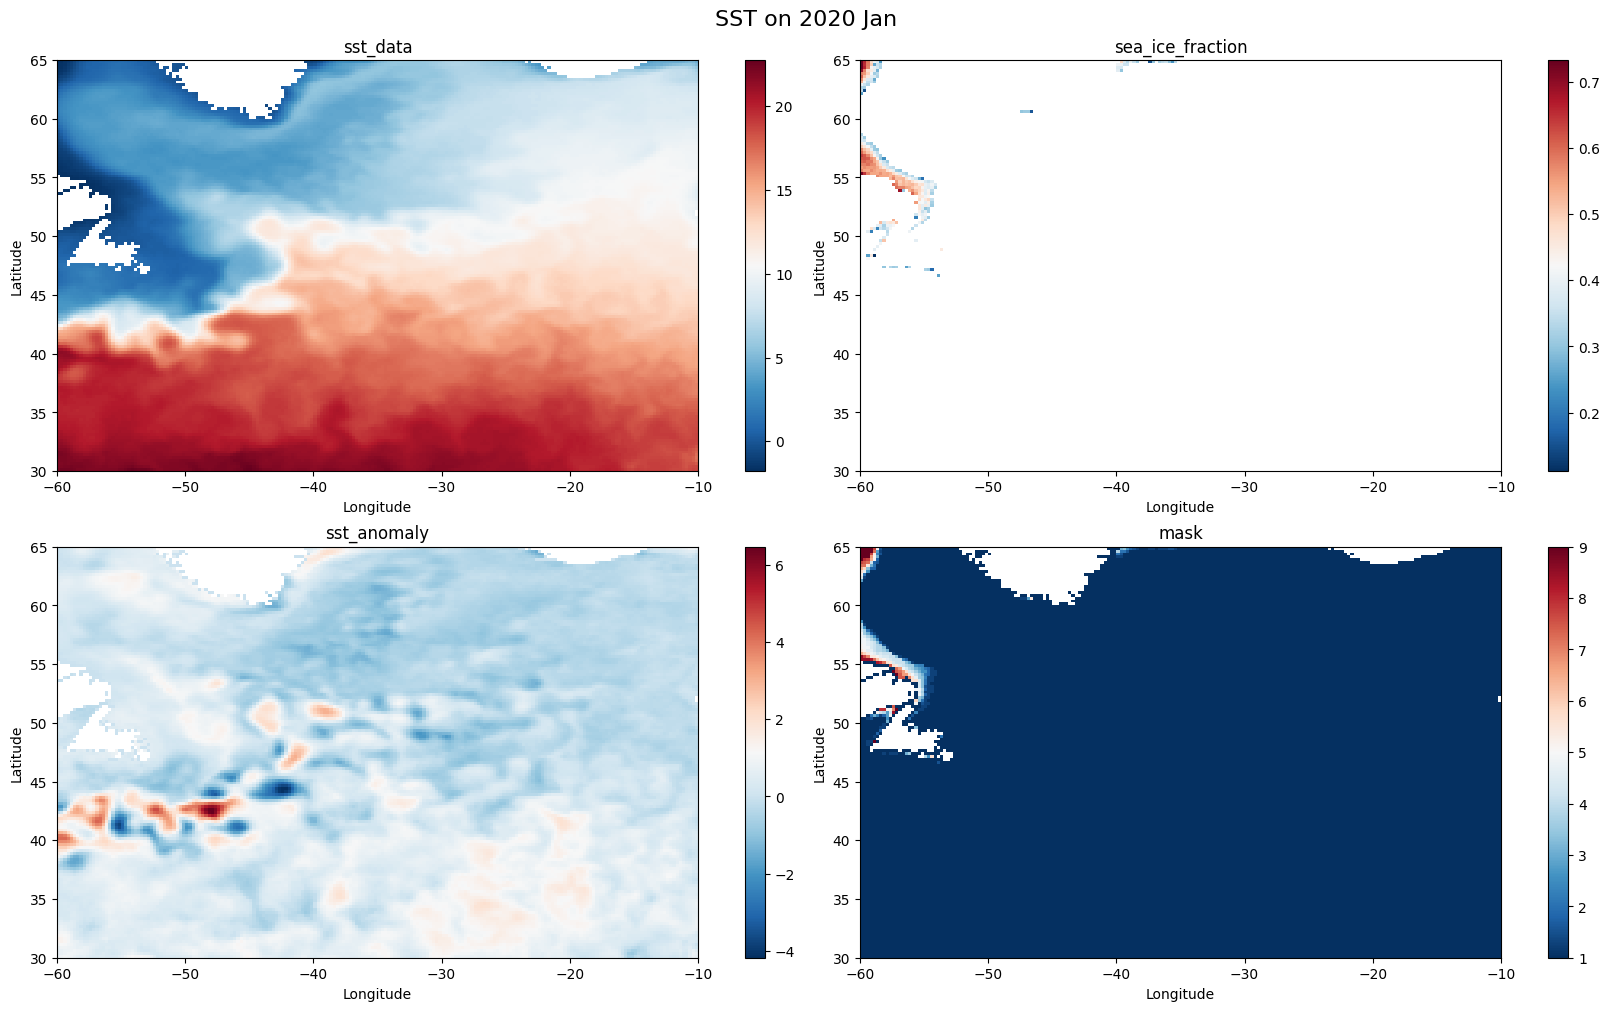

In [94]:

import numpy as np
import matplotlib.pyplot as plt

# Create sorted coordinate arrays
lon = np.sort(df_subset["lon"].unique())
lat = np.sort(df_subset["lat"].unique())

# Create 2D coordinate grid
Lon, Lat = np.meshgrid(lon, lat)

def grid_from_df(df, var):
    return (
        df
        .pivot(index="lat", columns="lon", values=var)
        .sort_index(ascending=True)
        .values
    )

sst_data  = grid_from_df(df_subset, "analysed_sst")
sea_ice_fraction  = grid_from_df(df_subset, "sea_ice_fraction")
sst_anomaly = grid_from_df(df_subset, "sst_anomaly")
mask = grid_from_df(df_subset, "mask")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
cmap = "RdBu_r"

plots = [
    ("sst_data",  sst_data,  axes[0,0]),
    ("sea_ice_fraction",  sea_ice_fraction,  axes[0,1]),
    ("sst_anomaly", sst_anomaly, axes[1,0]),
    ("mask", mask, axes[1,1]),
]

for title, data, ax in plots:
    pcm = ax.pcolormesh(
        Lon, Lat, data,
        shading="auto",
        cmap=cmap
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(pcm, ax=ax)

plt.suptitle(f"SST on 2020 Jan", fontsize=16)
plt.savefig("sst_plots.png", dpi=300, bbox_inches="tight")

plt.show()

In [4]:
df_subset.to_csv("df_sst.csv", index=False)